# Trabajo práctico integrador grupal

## Grupo 10

### Integrantes:
- Juan Pablo Bruno
- Mauro Joaquin Escudero
- Martin Glasser
- Federico Iglesias
- María Del Pilar Sassone

### Dataset elegido: Canciones de Spotify (clasificación)

## Análisis exploratorio de datos

Se cuentan con 6 datasets que contienen información de canciones de spotify agrupados por décadas de 1970 hasta 2010.

### Entendimiento de las propiedades de las canciones

| Nombre | Tipo | Rango | Descripción |
|---|---|---|---|
| **uri** | `texto` | `N/A` | ID único para identificar una canción |
| **track** | `texto` | `N/A` | Nombre de la canción |
| **artist** | `texto` | `N/A` | Intérprete de la canción |
| **danceability** | `numérica continua` | <code>(0,&nbsp;1)</code> | Describe qué tan adecuada es una canción para bailar, basándose en una combinación de elementos musicales como el tempo, la estabilidad del ritmo, la fuerza del beat y la regularidad general. Un valor de 0.0 indica que es poco bailable y 1.0 que es muy bailable |
| **energy** | `numérica continua` | <code>(0,&nbsp;1)</code> | Representa una medida perceptual de intensidad y actividad. Las canciones energéticas suelen sentirse rápidas, fuertes y ruidosas. Por ejemplo, el death metal tiene alta energía, mientras que un preludio de Bach puntúa bajo en esta escala |
| **key** | `numérica discreta` | <code>(-1,&nbsp;11)</code> | La tonalidad de la canción. Los enteros se mapean a notas musicales usando la notación de Clase de Tono estándar. Ej.: 0 = Do, 1 = Do♯/Re♭, 2 = Re, etc. Si no se detectó tonalidad, el valor es -1 |
| **loudness** | `numérica continua` | <code>(-60,&nbsp;0)&nbsp;dB</code> | El volumen general de una canción en decibeles (dB) |
| **mode** | `numérica discreta` | <code>{0,&nbsp;1}</code> | Indica la modalidad (mayor o menor) de una canción, el tipo de escala del que deriva su contenido melódico. El modo mayor se representa con 1 y el menor con 0 |
| **speechiness** | `numérica continua` | <code>(0,&nbsp;1)</code> | Detecta la presencia de palabras habladas en una canción. Cuanto más exclusivamente hablada sea la grabación (ej.: programa de radio, audiolibro, poesía), más cercano a 1.0 será el valor. Valores superiores a 0.66 describen canciones compuestas casi enteramente por palabras habladas. Entre 0.33 y 0.66 pueden contener música y habla. Por debajo de 0.33 representan principalmente música |
| **acousticness** | `numérica continua` | <code>(0,&nbsp;1)</code> | Medida de confianza de si la canción es acústica. 1.0 representa alta confianza de que la canción es acústica |
| **instrumentalness** | `numérica continua` | <code>(0,&nbsp;1)</code> | Predice si una canción no contiene voces. Los sonidos "ooh" y "aah" se tratan como instrumentales. Las canciones de rap o palabra hablada son claramente "vocales". Cuanto más cercano a 1.0, mayor es la probabilidad de que la canción no tenga contenido vocal |
| **liveness** | `numérica continua` | <code>(0,&nbsp;1)</code> | Detecta la presencia de audiencia en la grabación. Valores más altos indican mayor probabilidad de que la canción haya sido grabada en vivo. Un valor superior a 0.8 indica alta probabilidad de ser una grabación en vivo |
| **valence** | `numérica continua` | <code>(0,&nbsp;1)</code> | Describe la positividad musical transmitida por una canción. Las canciones con alta valencia suenan más positivas (ej.: alegres, eufóricas), mientras que las de baja valencia suenan más negativas (ej.: tristes, enojadas) |
| **tempo** | `numérica continua` | <code>>&nbsp;0&nbsp;BPM</code> | El tempo estimado de una canción en pulsaciones por minuto (BPM). En terminología musical, el tempo es la velocidad o ritmo de una pieza |
| **duration_ms** | `numérica discreta` | <code>>&nbsp;0&nbsp;ms</code> | Duración de la canción en milisegundos |
| **time_signature** | `numérica discreta` |  <code>(3,&nbsp;7)</code> | Compás estimado de la canción. El compás es una convención notacional que especifica cuántos tiempos hay en cada compás. El rango va de 3 a 7, indicando compases de 3/4 a 7/4 |
| **chorus_hit** | `numérica continua` | <code>>&nbsp;0</code> | Estimación del momento en que comienza el estribillo de la canción. Es el timestamp del inicio de la tercera sección (en milisegundos) |
| **sections** | `numérica discreta` | <code>>&nbsp;0</code> | El número de secciones que tiene la canción |
| **target** | `numérica discreta` | <code>{0,&nbsp;1}</code> | Variable objetivo. '1' indica que la canción apareció al menos una vez en la lista semanal Hot-100 de Billboard en esa década (hit). '0' indica que la canción no fue un éxito |
| **decade** | `texto` | <code>1960s&nbsp;-&nbsp;2010s</code> | Década a la que pertenece la canción |

Fuente: [Kaggle - The Spotify Hit Predictor Dataset (1960-2019)](https://www.kaggle.com/datasets/theoverman/the-spotify-hit-predictor-dataset)


### Importación de las librerías a utilizar

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Carga y unión de datasets

In [144]:
data_10 = pd.read_csv('datasets/dataset-of-10s.csv', index_col='uri')
data_00 = pd.read_csv('datasets/dataset-of-00s.csv', index_col='uri')
data_90 = pd.read_csv('datasets/dataset-of-90s.csv', index_col='uri')
data_80 = pd.read_csv('datasets/dataset-of-80s.csv', index_col='uri')
data_70 = pd.read_csv('datasets/dataset-of-70s.csv', index_col='uri')
data_60 = pd.read_csv('datasets/dataset-of-60s.csv', index_col='uri')

# Add a decade column to each dataframe
data_10['decade'] = '2010s'
data_00['decade'] = '2000s'
data_90['decade'] = '1990s'
data_80['decade'] = '1980s'
data_70['decade'] = '1970s'
data_60['decade'] = '1960s'

data = pd.concat([data_10, data_00, data_90, data_80, data_70, data_60])

# Add a duration column in minutes
data['duration'] = data['duration_ms'].apply(lambda x: x / 1000 / 60)

data.head()

,track,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target,decade,duration
uri,,,,,,,,,,,,,,,,,,,,
spotify:track:2ZyuwVvV6Z3XJaXIFbspeE,Wild Things,Alessia Cara,0.741,0.626,1,-4.826,0,0.0886,0.02000,0.000,0.0828,0.706,108.029,188493,4,41.18681,10,1,2010s,3.141550
spotify:track:61APOtq25SCMuK0V5w2Kgp,Surfboard,Esquivel!,0.447,0.247,5,-14.661,0,0.0346,0.87100,0.814,0.0946,0.250,155.489,176880,3,33.18083,9,0,2010s,2.948000
spotify:track:2JqnpexlO9dmvjUMCaLCLJ,Love Someone,Lukas Graham,0.550,0.415,9,-6.557,0,0.0520,0.16100,0.000,0.1080,0.274,172.065,205463,4,44.89147,9,1,2010s,3.424383
spotify:track:0cjfLhk8WJ3etPTCseKXtk,Music To My Ears (feat. Tory Lanez),Keys N Krates,0.502,0.648,0,-5.698,0,0.0527,0.00513,0.000,0.2040,0.291,91.837,193043,4,29.52521,7,0,2010s,3.217383
spotify:track:1lItf5ZXJc1by9SbPeljFd,Juju On That Beat (TZ Anthem),Zay Hilfigerrr & Zayion McCall,0.807,0.887,1,-3.892,1,0.2750,0.00381,0.000,0.3910,0.780,160.517,144244,4,24.99199,8,1,2010s,2.404067


### Distribuciones de las variables numéricas

Se analizan las distribuciones de las principales variables numéricas del dataset para entender su forma, rango y posibles anomalías.

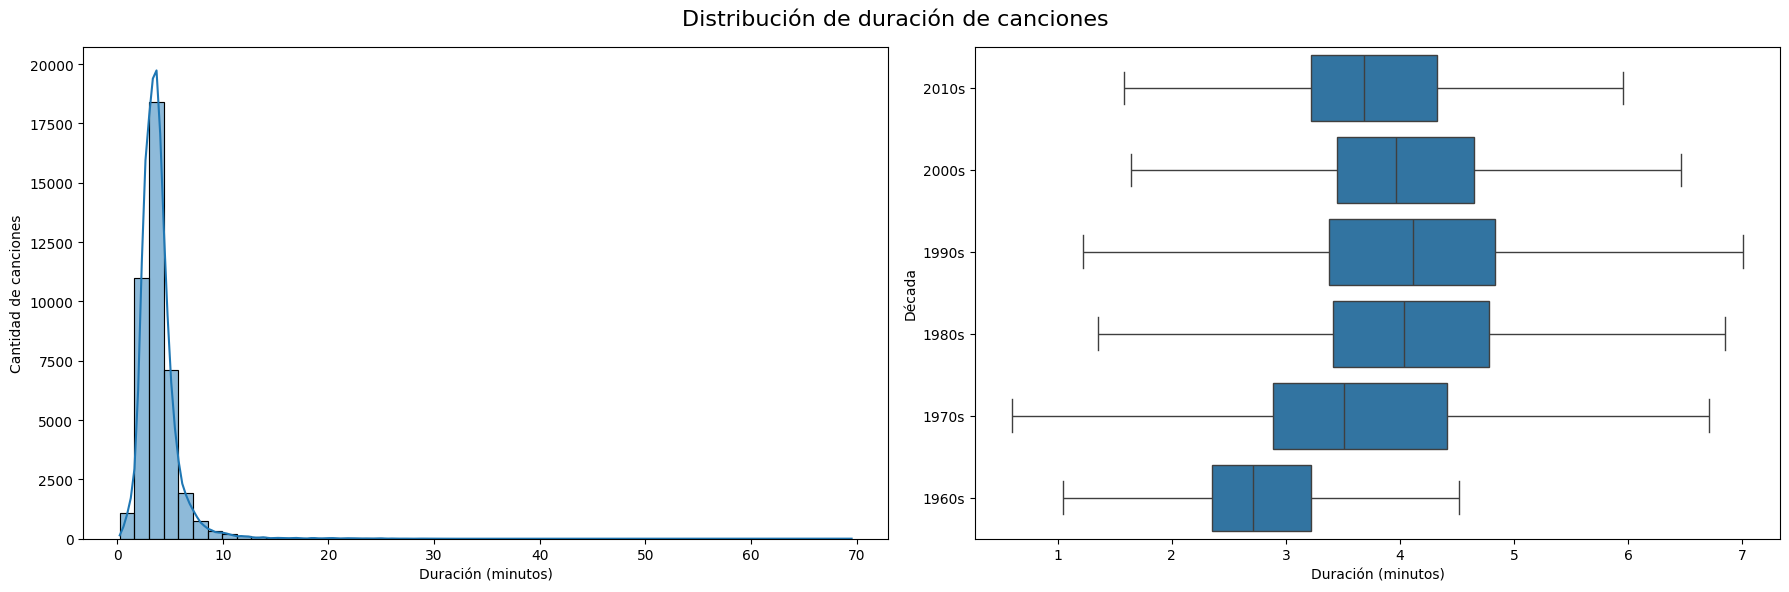

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribución de duración de canciones', fontsize=16)

axes[0].set_xlabel('Duración (minutos)')
axes[0].set_ylabel('Cantidad de canciones')
sns.histplot(data=data, x='duration', bins=50, kde=True, ax=axes[0])

axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('Década')
sns.boxplot(data=data, x='duration', y='decade', ax=axes[1], showfliers=False)

plt.tight_layout()
plt.show()

#### Observaciones sobre la distribución de duración

- La duración de las canciones presenta una distribución fuertemente asimétrica con una concentración entre los 2 y 5 minutos.
- Presenta outliers que alcanzan hasta los casi 70 minutos.
- Si dividimos las duraciones según la década podemos observar que en los 60s las canciones suelen durar casi 3 minutos, y en las décadas posteriores rondan los 4 minutos.

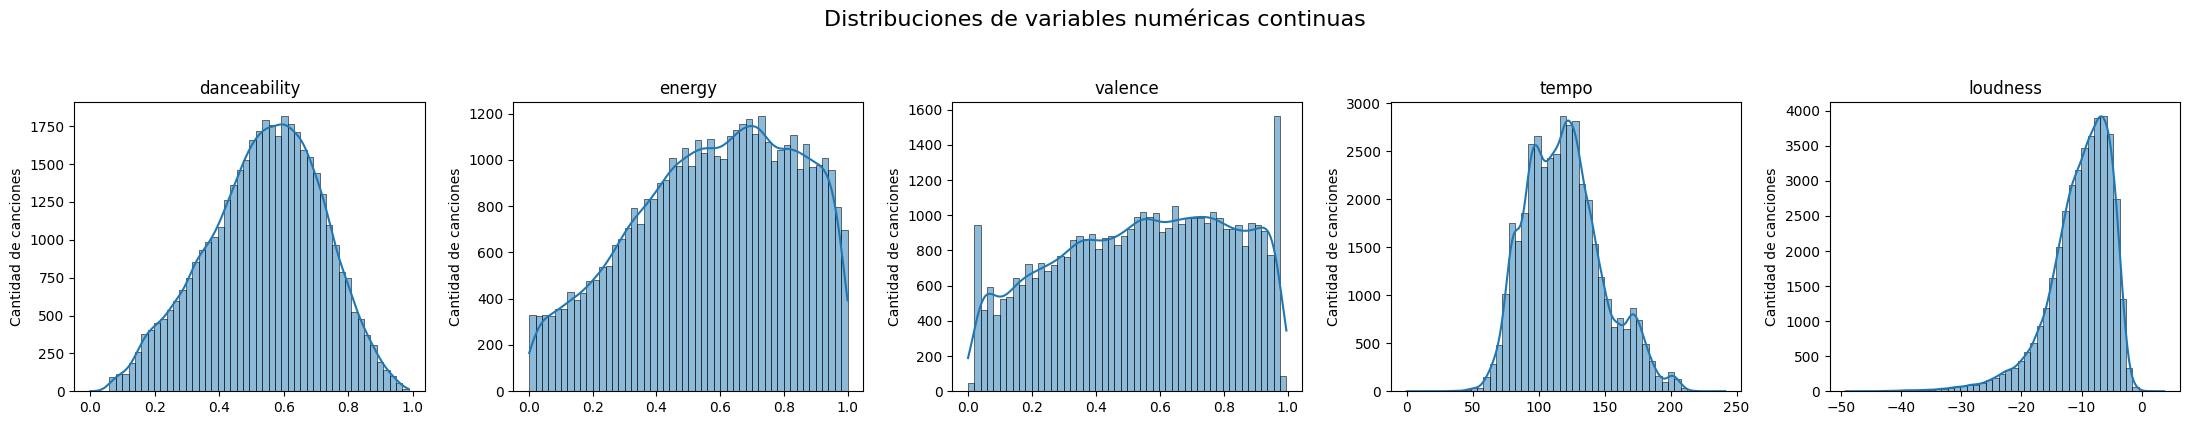

In [155]:
vars = ['danceability', 'energy', 'valence', 'tempo', 'loudness']
fig, axes = plt.subplots(1, len(vars), figsize=(22, 4))
fig.suptitle('Distribuciones de variables numéricas continuas', fontsize=16, y=1.05)

for i, var in enumerate(vars):
    ax = axes[i]
    sns.histplot(data=data, x=var, bins=50, kde=True, ax=ax)
    ax.set_title(var)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de canciones')

plt.tight_layout()
plt.show()

#### Observaciones sobre las distribuciones

- **danceability**: presenta una distribución aproximadamente simétrica, con valores repartidos a lo largo de todo el rango (0,1).
- **energy**: presenta una distribución asimétrica, con un pico entre 0.6 y 0.8, con valores repartidos a lo largo de todo el rango (0,1).
- **valence**: posee una distribución asimétrica, con valores repartidos a lo largo de todo el rango (0,1), con la presencia de algunos outliers.
- **tempo**: presenta una distribución aproximadamente simétrica, centrada entre 100 y 150 BPM.
- **loudness**: presenta una distribución asimétrica con una fuerte concentración entre -15 y 0 dB, con una cola larga hacia valores más negativos (canciones más silenciosas).

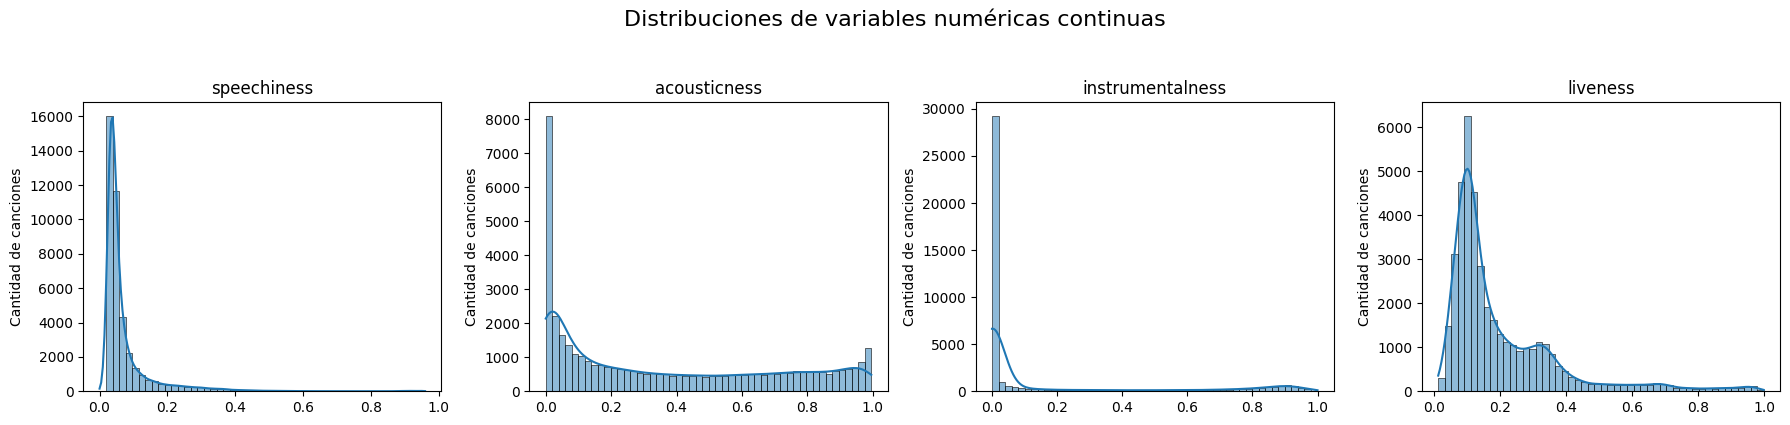

In [146]:
vars = ['speechiness', 'acousticness', 'instrumentalness', 'liveness']
fig, axes = plt.subplots(1, len(vars), figsize=(18, 4))
fig.suptitle('Distribuciones de variables numéricas continuas', fontsize=16, y=1.05)

for i, var in enumerate(vars):
    ax = axes[i]
    sns.histplot(data=data, x=var, bins=50, kde=True, ax=ax)
    ax.set_title(var)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de canciones')

plt.tight_layout()
plt.show()

#### Observaciones sobre las distribuciones

- **speechiness**: presenta una distribución fuertemente asimétrica con concentración cerca de 0, lo que indica que la mayoría de las canciones tienen poca habla.
- **acousticness**: presenta una distribución asimétrica con una concentración en valores muy bajos, lo que indica que hay un gran número de canciones poco acústicas.
- **instrumentalness**: presenta una distribución fuertemente asimétrica con concentración cerca de 0, lo que indica que la mayoría de las canciones son instrumentales.
- **liveness**: presenta una distribución fuertemente asimétrica con concentración entre 0 y 0.2, lo que indica que la mayoría de las canciones no son en vivo.

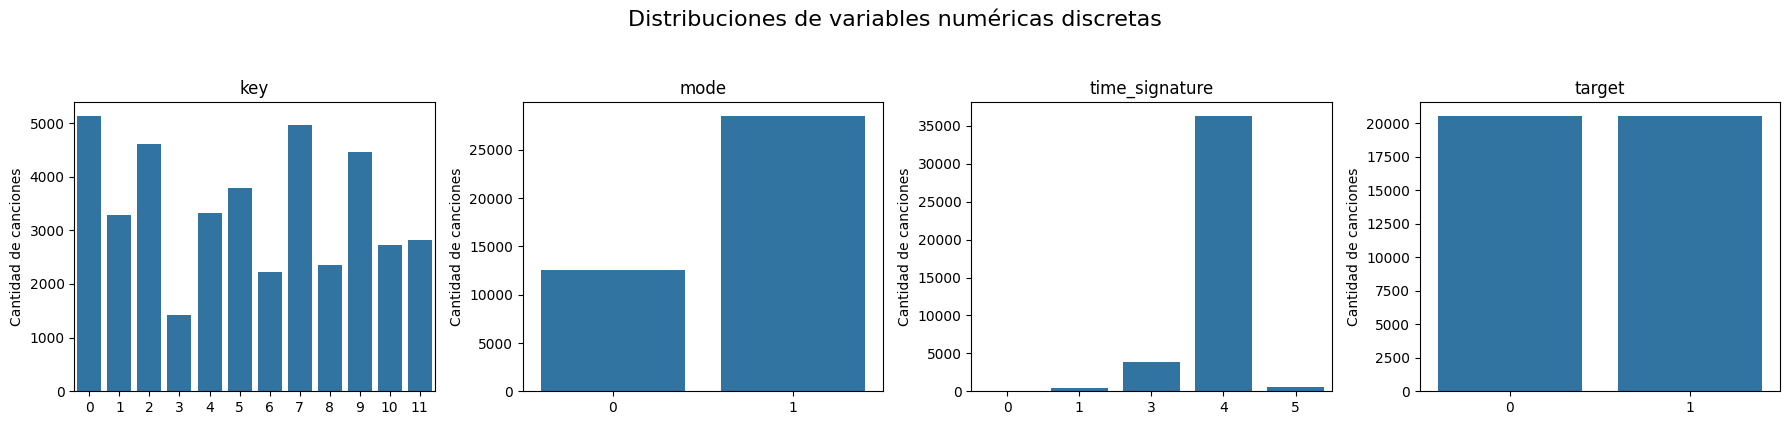

In [147]:
vars = ['key', 'mode', 'time_signature', 'target']
fig, axes = plt.subplots(1, len(vars), figsize=(18, 4))
fig.suptitle('Distribuciones de variables numéricas discretas', fontsize=16, y=1.05)

for i, var in enumerate(vars):
    ax = axes[i]
    sns.countplot(data=data, x=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de canciones')

plt.tight_layout()
plt.show()

#### Observaciones sobre las distribuciones

- **key**: se distribuye de manera relativamente uniforme entre las 12 tonalidades, con Do (0) y Sol (7) como las más frecuentes y Re♭ (3) como la menos frecuente.
- **mode**: presenta un desbalance: hay más canciones en modo mayor (1) que menor (0), en una proporción aproximada de 70/30.
- **time_signature**: está dominada ampliamente por el compás de 4/4, como es esperable en música popular.
- **target**: está balanceado, la cantidad de hits y no-hits es prácticamente igual.

### Análisis de valores nulos

Se verifica la presencia de valores nulos en el dataset para determinar si es necesaria alguna estrategia de imputación.

In [148]:
null_cnt = data.isnull().sum()
null_pct = (data.isnull().sum() / len(data) * 100).round(2)
null_sum = pd.DataFrame({'Nulos': null_cnt, '% Nulos': null_pct})

print(f"Total de registros: {len(data)}")
print(f"Total de valores nulos en el dataset: {null_cnt.sum()}\n")
null_sum

Total de registros: 41106
Total de valores nulos en el dataset: 0



,Nulos,% Nulos
track,0,0.0
artist,0,0.0
danceability,0,0.0
energy,0,0.0
key,0,0.0
loudness,0,0.0
mode,0,0.0
speechiness,0,0.0
acousticness,0,0.0
instrumentalness,0,0.0


#### Conclusión sobre valores nulos

El dataset **no presenta valores nulos** en ninguna de sus columnas, por lo que no es necesario aplicar estrategias de imputación.

### Análisis de valores extremos (Outliers)

Se utilizan boxplots y el método del rango intercuartílico (IQR) para identificar outliers en las variables numéricas continuas.

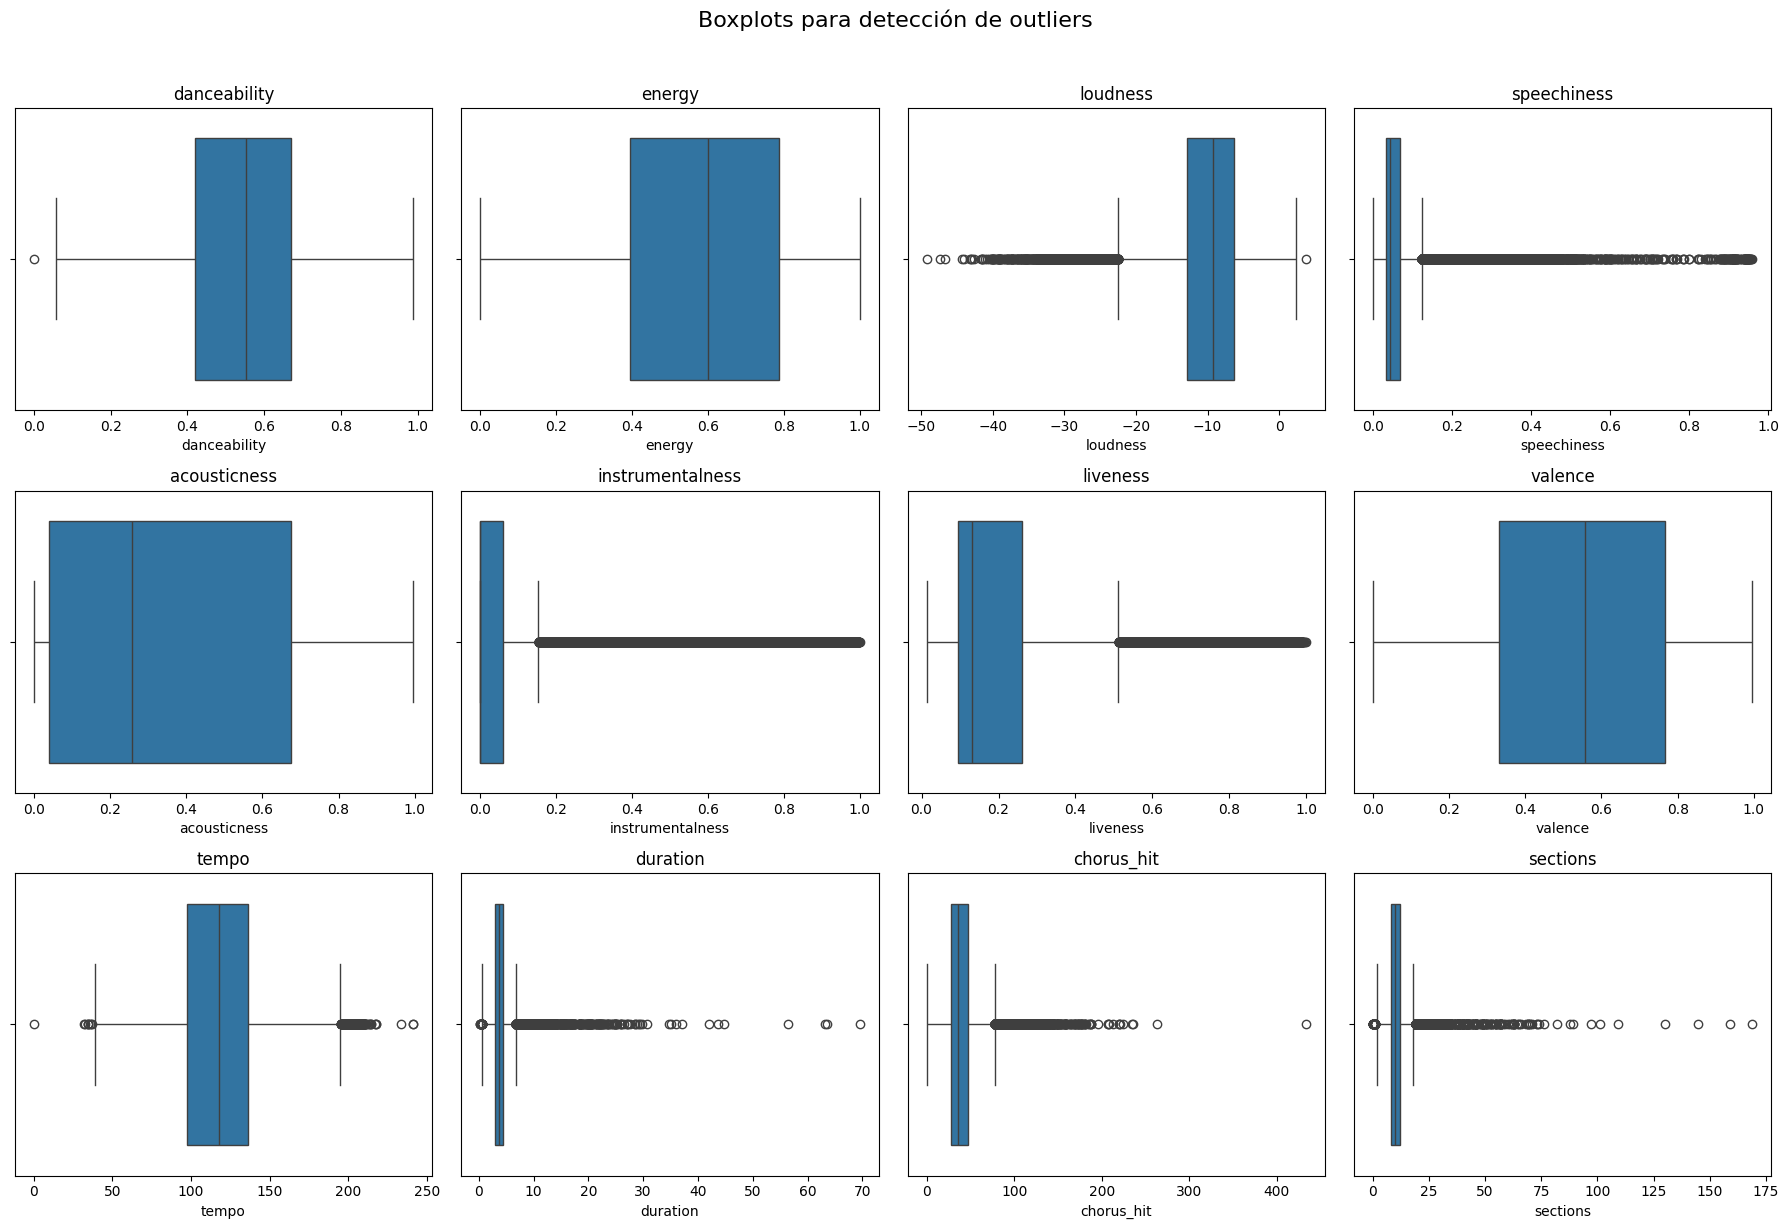

In [149]:
outlier_vars = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration', 'chorus_hit', 'sections']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Boxplots para detección de outliers', fontsize=16, y=1.02)

for i, var in enumerate(outlier_vars):
    ax = axes[i // 4, i % 4]
    sns.boxplot(data=data, x=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [150]:
# Cuantificación de outliers por método IQR
outlier_summary = []

for var in outlier_vars:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data[var] < lower) | (data[var] > upper)).sum()
    pct = round(n_outliers / len(data) * 100, 2)
    outlier_summary.append({
        'Variable': var,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Límite inferior': round(lower, 4),
        'Límite superior': round(upper, 4),
        'Outliers': n_outliers,
        '% Outliers': pct
    })

pd.DataFrame(outlier_summary).sort_values('% Outliers', ascending=False).reset_index(drop=True)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% Outliers
0,instrumentalness,0.0000,0.0612,0.0612,-0.0919,0.1531,8920,21.70
1,speechiness,0.0337,0.0698,0.0361,-0.0205,0.1240,5088,12.38
2,liveness,0.0940,0.2610,0.1670,-0.1565,0.5115,2688,6.54
3,duration,2.8821,4.4462,1.5641,0.5360,6.7923,1987,4.83
4,chorus_hit,27.5998,47.6256,20.0258,-2.4389,77.6643,1839,4.47
5,sections,8.0000,12.0000,4.0000,2.0000,18.0000,1570,3.82
6,loudness,-12.8160,-6.3742,6.4418,-22.4786,3.2884,1343,3.27
7,tempo,97.3970,136.4940,39.0970,38.7515,195.1395,434,1.06
8,danceability,0.4200,0.6690,0.2490,0.0465,1.0425,1,0.00
9,energy,0.3960,0.7870,0.3910,-0.1905,1.3735,0,0.00


#### Observaciones sobre outliers

Las variables con mayor proporción de outliers (según el método IQR) son:
- **instrumentalness** y **speechiness**: presentan un alto porcentaje de outliers, pero esto se debe a la naturaleza de sus distribuciones. Son valores válidos que representan canciones instrumentales o con mucha habla.
- **danceability**, **energy**, **acousticness** y **valence**: prácticamente no tienen outliers, lo que indica distribuciones más uniformes.

### Relación de features con el target

Se analiza cómo se distribuyen las variables numéricas según la variable objetivo (`target`): hit (1) vs no hit (0). Se utilizan violinplots para visualizar las diferencias en las distribuciones.

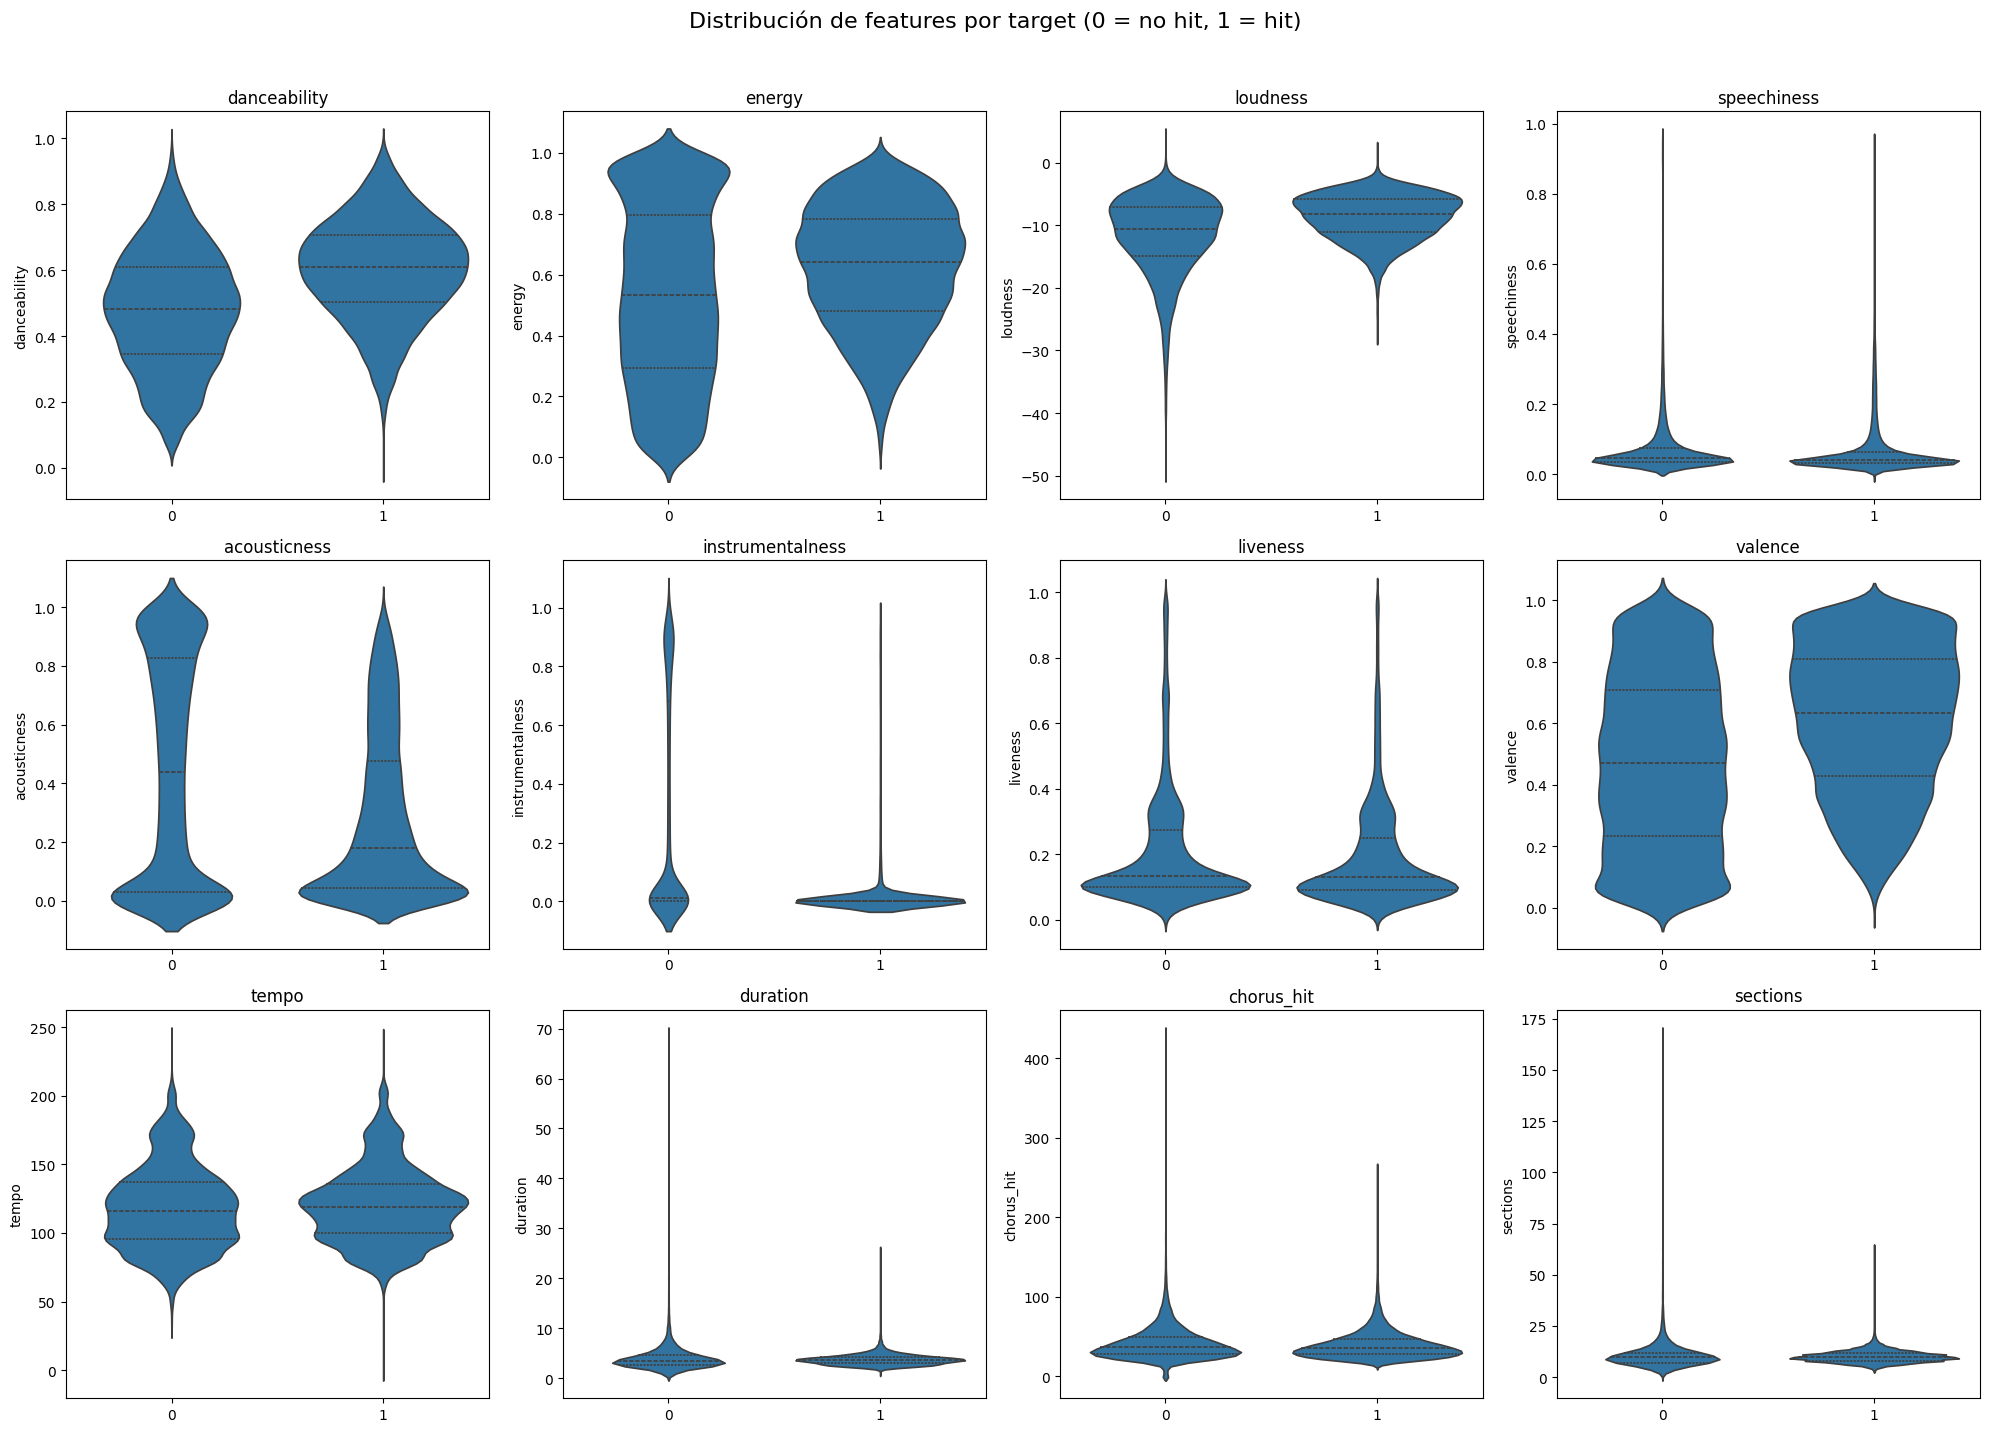

In [151]:
feature_vars = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration', 'chorus_hit', 'sections']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Distribución de features por target (0 = no hit, 1 = hit)', fontsize=16, y=1.02)

for i, var in enumerate(feature_vars):
    ax = axes[i // 4, i % 4]
    sns.violinplot(data=data, x='target', y=var, ax=ax, inner='quartile')
    ax.set_title(var)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [152]:
# Comparación de medianas por target
comparison = data.groupby('target')[feature_vars].median().T
comparison.columns = ['No Hit (0)', 'Hit (1)']
comparison['Diferencia'] = comparison['Hit (1)'] - comparison['No Hit (0)']
comparison['Dif %'] = ((comparison['Diferencia'] / comparison['No Hit (0)']) * 100).round(1)
comparison

,No Hit (0),Hit (1),Diferencia,Dif %
danceability,0.483000,0.610000,0.127000,26.3
energy,0.533000,0.642000,0.109000,20.5
loudness,-10.664000,-8.273000,2.391000,-22.4
speechiness,0.046000,0.040600,-0.005400,-11.7
acousticness,0.439000,0.181000,-0.258000,-58.8
instrumentalness,0.010500,0.000006,-0.010494,-99.9
liveness,0.134000,0.130000,-0.004000,-3.0
valence,0.470000,0.633000,0.163000,34.7
tempo,115.906000,118.881000,2.975000,2.6
duration,3.566667,3.674000,0.107333,3.0


#### Observaciones sobre la relación features-target

Las variables que muestran mayor diferencia entre hits y no hits son:

**Features con valores más altos en hits:**
- **danceability** (+26.3%): Los hits tienden a ser más bailables.
- **valence** (+34.4%): Los hits transmiten mayor positividad musical.
- **energy** (+20.9%): Los hits son más energéticos.
- **loudness** (+22.5% más fuerte): Los hits son más fuertes en volumen (más cercanos a 0 dB).

**Features con valores más bajos en hits:**
- **acousticness** (-59.0%): Los hits tienden a ser mucho menos acústicos.
- **instrumentalness** (-99.9%): Los hits son casi exclusivamente vocales.

**Features con poca diferencia:**
- **tempo**, **duration**, **chorus_hit**, **liveness** y **sections** muestran diferencias mínimas entre hits y no hits, lo que sugiere menor poder discriminativo.

Esto indica que las canciones exitosas tienden a ser **más bailables, positivas, energéticas, fuertes y menos acústicas/instrumentales**.

### Correlaciones entre variables

Se analiza la matriz de correlación de Pearson para identificar relaciones lineales entre las variables numéricas y detectar posibles problemas de multicolinealidad.

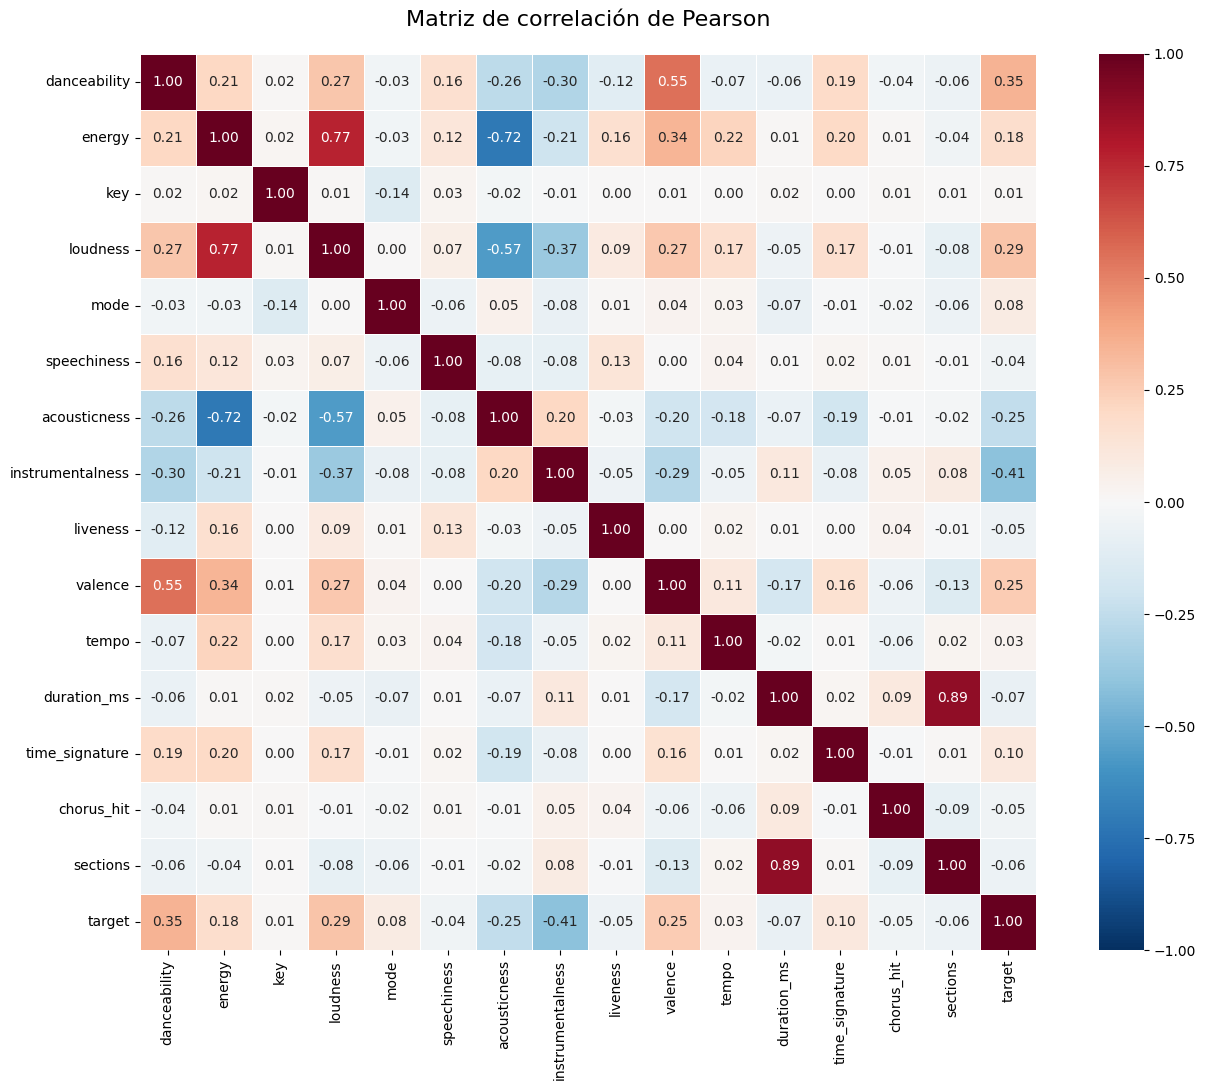

In [174]:
numeric_cols = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target']

corr_matrix = data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación de Pearson', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Correlaciones con el target, ordenadas por valor absoluto
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("Correlaciones con target (ordenadas por valor absoluto):\n")
print(target_corr.round(2).to_string())

Correlaciones con target (ordenadas por valor absoluto):

instrumentalness   -0.41
danceability        0.35
loudness            0.29
valence             0.25
acousticness       -0.25
energy              0.18
time_signature      0.10
mode                0.08
duration_ms        -0.07
sections           -0.06
liveness           -0.05
chorus_hit         -0.05
speechiness        -0.04
tempo               0.03
key                 0.01


In [ ]:
corrs = data[numeric_cols].corr()
relevant = []
for var1 in numeric_cols:
  for var2 in numeric_cols:
    if var1 != var2:
      corr_value = corrs[var1][var2]
      if abs(corrs[var1][var2]) >= 0.5 and var1 != 'target' and var2 != 'target':
        if not any((var1 == v1 and var2 == v2) or (var1 == v2 and var2 == v1) for v1, v2 in relevant):
          relevant.append((var1, var2))

print("Correlaciones entre variables (|r| >= 0.5, excluyendo target):\n")
for var1, var2 in relevant:
  print(f'{var1} ↔ {var2}: {round(corrs[var1][var2], 2)}')        

Correlaciones entre variables (|r| >= 0.5, excluyendo target):

danceability ↔ valence: 0.55
energy ↔ loudness: 0.77
energy ↔ acousticness: -0.72
loudness ↔ acousticness: -0.57
duration_ms ↔ sections: 0.89


#### Observaciones sobre las correlaciones

**Correlaciones más relevantes con el target:**
- **instrumentalness** (-0.41): La correlación negativa más fuerte, las canciones instrumentales tienen muchas menos chances de ser hits.
- **danceability** (+0.35): Las canciones más bailables tienden a ser más exitosas.
- **loudness** (+0.29): Las canciones más fuertes en volumen se asocian con mayor éxito.
- **valence** (+0.25): Las canciones con mayor positividad musical tienden a ser hits.
- **acousticness** (-0.25): Las canciones acústicas tienen menor probabilidad de ser hits.

**Correlaciones entre features (multicolinealidad):**
- **duration_ms ↔ sections** (0.89): Correlación muy alta, canciones más largas tienen más secciones.
- **energy ↔ loudness** (0.77): Correlación alta, las canciones más energéticas son más fuertes.
- **energy ↔ acousticness** (-0.72): Correlación inversa alta, las canciones acústicas tienden a ser poco energéticas.
- **loudness ↔ acousticness** (-0.57): Correlación inversa moderada, las canciones más bajas tienden a ser acústicas.
- **danceability ↔ valence** (0.55): Correlación moderada, las canciones bailables tienden a ser más positivas.